In [ ]:
import pandas as pd
import optuna
import matplotlib.pyplot as plt
import shap
from sklearn.model_selection import train_test_split,GridSearchCV,StratifiedKFold, KFold,cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
import xgboost as xgb
from sklearn.preprocessing import StandardScaler, LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
import matplotlib as mpl
from matplotlib import font_manager
import lightgbm as lgb
import warnings
import math
import os
import re
import json
import numpy as np


from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
data_path = f'/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/{dataset}'
# data_path = '/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/final_data2/filtered_patient2.csv'
filtered_df = pd.read_csv(data_path)

# 注册中文字体到matplotlib
font_path = "/System/Library/Fonts/Supplemental/Songti.ttc"
mpl.font_manager.fontManager.addfont(font_path)
prop = font_manager.FontProperties(fname=font_path)
font_name = prop.get_name()
print("matplotlib 识别的字体名:", font_name)

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False

matplotlib 识别的字体名: Songti SC


In [120]:
# 提取当前数据集的数字
def extract_integers(s: str):
    """
    从字符串中提取所有整数，返回一个 int 列表
    """
    return list(map(int, re.findall(r"\d+", s)))


In [121]:
def label_encoding(filtered_df, data_path):
    columns_to_change1 = [item for item in filtered_df if item.endswith('_定性')]
    columns_to_change2 = [item for item in filtered_df if item.endswith('_描述性')]

    # 对每个object类型的列进行Label Encoding
    object_columns = columns_to_change1+columns_to_change2
    if 'filtered_patient1' in data_path or 'filtered_patient2' in data_path or 'filtered_patient5' in data_path:
        object_columns.remove('脑脊液_透明度_描述性')
        object_columns.remove('脑脊液_蛋白定性_定性')

    features_to_change = [ '血_抗双链DNA抗体_定性', '血_抗核抗体_定性', '血_抗胞浆型中性粒细胞抗体_定性', '血_抗核周型中性粒细胞抗体_定性', '血_梅毒非特异性抗体_定性', '血_梅毒螺旋体抗体_定性',
                        '血_人类免疫缺陷病毒抗体_定性', '血_不规则抗体_定性', '血_直接抗人球蛋白试验_定性', '血_结核感染T细胞检测_定性', '血_人类免疫缺陷病毒P24抗原_定性', '血_M蛋白_描述性']

    if 'filtered_patient2' in data_path or 'filtered_patient4' in data_path:
        for i in features_to_change:
            object_columns.remove(i)

    le_dict = {}
    for col in object_columns:
        le = LabelEncoder()
        # 处理空值：先用'unknown'填充，再进行编码
        filtered_df[col] = filtered_df[col].fillna('unknown')
        filtered_df[col] = le.fit_transform(filtered_df[col].astype(str))  # 确保没有NaN，否则会报错
        le_dict[col] = le  # 保存编码器，后续可能用于推理
    
    return filtered_df
    

In [122]:

# 替换特征名中的 [，]
def clean_feature_names_simple(feature_names):
    cleaned_names = []
    for name in feature_names:
        cleaned_name = name.replace('[', '').replace(']', '').replace('<', '').replace('>', '')
        cleaned_names.append(cleaned_name)
    return cleaned_names

    
    # filtered_df.columns = clean_feature_names_simple(filtered_df.columns)
    # print("清洗后的列名:", filtered_df.columns.tolist())



In [123]:
def XGBoost_train(X_train, y_train, X_val, y_val, key):
    # 定义 Optuna 目标函数
    def objective(trial):
        # 建议超参数范围
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 10, 200, step=10),
            'max_depth': trial.suggest_int('max_depth', 2, 10),
            'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
            'subsample': trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            'gamma': trial.suggest_float('gamma', 0.0, 5.0),
            'random_state': 42,
            # 'use_label_encoder': False,
            'eval_metric': ['auc', 'logloss']
            # 'scale_pos_weight':
        }
        

        model = xgb.XGBClassifier(**params)
        # model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)], verbose=False)
    
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        auc = cross_val_score(model, X_train, y_train, cv=cv,
                          scoring="roc_auc", n_jobs=-1).mean()
    
        # evals_result = model.evals_result()

        # train_logloss = evals_result['validation_0']['logloss']
        # val_logloss = evals_result['validation_1']['logloss']

        # train_auc = evals_result['validation_0']['auc']
        # val_auc = evals_result['validation_1']['auc']
        
        # context = ""

        # for key1, item1 in params.items():
        #     if key1 == 'use_label_encoder' or key1 == 'eval_metric':
        #         context = f"{context}{key1}:{item1}\n"
        #     else:
        #         # print(item1)
        #         context = f"{context}{key1}:{item1:.3f}\n"

        # best_auc = 0
        # for i in range(len(val_auc)):
        #     if val_auc[i] > best_auc:
        #         best_auc = val_auc[i]
        #         params['n_estimators'] = i

        # # 绘制损失曲线和AUC的变化
        # plt.figure(figsize=(8, 5))
        # plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
        # plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
        # plt.xlabel('轮数')
        # plt.ylabel('损失')
        # plt.title(f'{key}损失曲线（拟合情况）')
        # plt.text(len(train_logloss) - len(train_logloss)/10, train_logloss[-1]+0.02, f"AUC:{best_auc:.2f}", fontsize=12)
        # plt.text(len(train_logloss)/2, train_logloss[1]-(train_logloss[1]-train_logloss[-1])*0.35, f"param:{context}", fontsize=9)
        # plt.legend()
        # plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/Train/Loss/{key}损失情况{trial.number}.png", dpi=300, bbox_inches='tight')  # 保存为PNG
        

        # plt.figure(figsize=(8, 5))
        # plt.plot(range(1, len(train_auc) + 1), train_auc, label=f'Train AUC: {train_auc[-1]:.4f}')
        # plt.plot(range(1, len(val_auc) + 1), val_auc, label=f'Validation AUC: {best_auc:.4f}')
        # plt.xlabel('轮数')
        # plt.ylabel('AUC')
        # plt.title(f'{key}AUC变化情况')
        # plt.grid(True, alpha=0.3)
        # plt.text(len(train_auc)/2, train_auc[1]-(train_auc[1]-train_auc[-1])*0.35, f"param:{context}", fontsize=9)
        # plt.legend()
        # plt.savefig(f"/Users/yanjieni/Desktop/脑脊液/naojiye/images/XGBoost/Train/AUC/{key}AUC变化{trial.number}.png", dpi=300, bbox_inches='tight')  # 保存为PNG

        return 1.0 - auc

    # 创建 Optuna 研究
    study = optuna.create_study(
        direction='minimize',  # 最小化目标函数 (1 - AUC)
        sampler=optuna.samplers.TPESampler(seed=42),
        pruner=optuna.pruners.MedianPruner(n_warmup_steps=10)  # 10轮后开始剪枝
    )

    # 运行优化
    print("开始超参数优化...")
    study.optimize(objective, n_trials=100, show_progress_bar=True)

    # 输出最佳结果
    print("\n优化完成!")
    print("Number of finished trials: ", len(study.trials))
    print("Best trial:")
    best_trial = study.best_trial
    print(f"  Best AUC: {1 - best_trial.value:.4f}")  # 转换回 AUC
    print("  Best params: ")
    for key, value in best_trial.params.items():
        print(f"    {key}: {value}")

    # 使用最佳参数重新训练最终模型
    print("\n使用最佳参数训练最终模型...")
    best_params = best_trial.params
    best_params['random_state'] = 42

    # final_model = xgb.XGBClassifier(**best_params)
    # final_model.fit(X_train, y_train)
    # best_model = grid_xgb.best_estimator_     
    # return [final_model,best_trial.params,best_params]

    best_model = xgb.XGBClassifier(**best_params)

    return best_model



In [124]:
# 构建处理空值的Pipeline
def create_pipeline(X_train, y_train):
    # 创建完整的模型管道
    model_pipeline = Pipeline(steps=[
        # ('preprocessor', preprocessor),
        ('imputer', KNNImputer(n_neighbors=5)),  # 使用KNN填充数值型空值
        # ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(random_state=42, max_iter=1000))
    ])

    print("预处理管道构建完成")

    # 定义参数网格
    param_grid = {
        'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1', 'l2'],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    }

    # 创建网格搜索对象
    print("开始超参数优化...")
    grid_search = GridSearchCV(
        model_pipeline, 
        param_grid, 
        cv=5, 
        scoring='roc_auc', 
        n_jobs=-1, 
        verbose=1
    )

    # 训练模型
    grid_search.fit(X_train, y_train)

    # 输出最佳结果
    print("\n优化完成!")
    print(f"最佳参数: {grid_search.best_params_}")
    print(f"最佳交叉验证AUC: {grid_search.best_score_:.4f}")

    # 获取最佳模型
    final_model = grid_search.best_estimator_
    return final_model
    

In [ ]:
import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc

def bootstrap_auc_ci(y_true, y_score, B=1000, seed=2025, return_distribution=False):
    """
    Bootstrap percentile CI for ROC-AUC with stratified resampling on the test set.
    y_true: 1D array of {0,1}
    y_score: 1D array of predicted probabilities for class 1
    """
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    # 原始整套测试集点估计
    auc_point = roc_auc_score(y_true, y_score)

    pos_idx = np.where(y_true == 1)[0]
    neg_idx = np.where(y_true == 0)[0]
    n_pos, n_neg = len(pos_idx), len(neg_idx)

    aucs = np.empty(B, dtype=float)
    for b in range(B):
        # 分层有放回采样，保持类样本量不变
        boot_pos = rng.choice(pos_idx, size=n_pos, replace=True)
        boot_neg = rng.choice(neg_idx, size=n_neg, replace=True)
        boot_idx = np.concatenate([boot_pos, boot_neg])

        # 计算本次 AUC
        aucs[b] = roc_auc_score(y_true[boot_idx], y_score[boot_idx])

    # 百分位 CI
    lower, median, upper = np.percentile(aucs, [2.5, 50.0, 97.5])
    if return_distribution:
        return {"point": auc_point, "median": median, "ci95": (lower, upper), "all": aucs}
    else:
        return {"point": auc_point, "median": median, "ci95": (lower, upper)}



In [ ]:
def mix_model(xgb, lr, X_train, y_train, X_test, y_test, dataset_name):
    base_models = [
        ("xgb", xgb),
        ("lr", lr)
    ]

    n_splits = 5
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)

    oof_preds = np.zeros((X_train.shape[0], len(base_models)))
    test_preds = np.zeros((X_test.shape[0], len(base_models)))

    for model_idx, (name, model) in enumerate(base_models):
        test_fold_preds = np.zeros((X_test.shape[0], n_splits))

        for fold, (train_idx, valid_idx) in enumerate(kf.split(X_train)):
            X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[valid_idx]
            y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[valid_idx]

            model.fit(X_tr, y_tr)
            oof_preds[valid_idx, model_idx] = model.predict_proba(X_val)[:, 1]
            test_fold_preds[:, fold] = model.predict_proba(X_test)[:, 1]

        test_preds[:, model_idx] = test_fold_preds.mean(axis=1)

    # 二层模型：
    mixed_model = LogisticRegression(random_state=42, max_iter=1000)
    mixed_model.fit(oof_preds, y_train)
    final_pred = mixed_model.predict_proba(test_preds)[:, 1]    
    
    # 最佳阈值
    best_thresh, best_f1 = 0.5, 0
    for thresh in np.arange(0.01, 0.99, 0.01):
        pred_val = (final_pred > thresh).astype(int)
        f1 = f1_score(y_test, pred_val)
        if f1 > best_f1:
            best_thresh, best_f1 = thresh, f1

    print(f"最佳阈值: {best_thresh:.2f}，测试集最大f1: {best_f1:.4f}")
    
     
    y_pred = (final_pred >= best_thresh).astype(int)


    # ========== 6. 结果 ==========
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, final_pred)
    res_auc = bootstrap_auc_ci(y_test, final_pred, B=1000, seed=2025)
    print(f"AUC = {res_auc['point']:.3f} "
        f"(95% CI {res_auc['ci95'][0]:.3f}–{res_auc['ci95'][1]:.3f})")

   
    print(f"\n{dataset_name} 集评估结果:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"AUC: {roc_auc:.4f}")

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'auc': roc_auc,
        'y_pred': y_pred,
        'y_pred_proba': final_pred,
        'mixed_model': mixed_model,
        'test_preds': test_preds,
        'CI': (round(res_auc['ci95'][0],4),round(res_auc['ci95'][1],4))
    }



In [ ]:
def draw_result(y_val, y_test, val_results, test_results, key, current_dataset):

    # 绘制ROC曲线
    plt.figure(figsize=(10, 8))

    # 计算各数据集的ROC曲线
    fpr_val, tpr_val, thresholds = roc_curve(y_val, val_results['y_pred_proba'])
    fpr_test, tpr_test, thresholds = roc_curve(y_test, test_results['y_pred_proba'])

    pd.DataFrame({
        "fpr": fpr_test,
        "tpr": tpr_test,
        "threshold": thresholds  
    }).to_csv(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/ROC/LR+XGBoost2/{key}/Dataset{current_dataset}_roc_curve.csv", index=False)


    # 绘制ROC曲线
    plt.plot(fpr_val, tpr_val, color='blue', lw=2, 
            label=f'验证集 AUC = {val_results["auc"]:.4f}')
    plt.plot(fpr_test, tpr_test, color='red', lw=2, 
            label=f'测试集 AUC = {test_results["auc"]:.4f}')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=2)

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title(f'{key} - LR_XGBoost2 ROC曲线', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR_XGBoost2/ROC_AUC/Dataset{current_dataset}/{key}ROC-AUC.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()

    model = key
    data_to_append = {'val_accuracy':round(val_results['accuracy'],4),'val_precision':round(val_results['precision'],4),'val_recall':round(val_results['recall'],4),'val_f1':round(val_results['f1'],4),'roc_auc_val':round(val_results['auc'],4),'val_CI':val_results['CI'],
                    'test_accuracy':round(test_results['accuracy'],4),'test_precision':round(test_results['precision'],4),'test_recall':round(test_results['recall'],4),'test_f1':round(test_results['f1'],4),'roc_auc_test':round(test_results['auc'],4),'test_CI':test_results['CI']}
    # JSON 文件路径
    json_file = "/Users/yanjieni/Desktop/projects/脑脊液/naojiye/data/model_data4/LR_XGBoost2_data.json"

    # 如果文件存在，先读取已有数组，否则初始化为空列表
    if os.path.exists(json_file):
        with open(json_file, "r", encoding="utf-8") as f:
            try:
                existing_data = json.load(f)
                if f'LR_XGBoost2_Dataset{current_dataset}' not in existing_data:
                    existing_data[f'LR_XGBoost2_Dataset{current_dataset}'] = {}
            except json.JSONDecodeError:
                existing_data = {f'LR_XGBoost2_Dataset{current_dataset}':{}}
    else:
        existing_data = {f'LR_XGBoost2_Dataset{current_dataset}':{}}

    # 追加新的数据
    existing_data[f'LR_XGBoost2_Dataset{current_dataset}'][model] = data_to_append
    # print(existing_data)
    # 写回 JSON 文件
    with open(json_file, "w", encoding="utf-8") as f:
        json.dump(existing_data, f, ensure_ascii=False, indent=4)



In [ ]:
def depned_on(best_xgb, best_lr, X_test,meta_model,test_preds,current_dataset,key):

    # # ========== 1. SHAP for XGB ==========
    # explainer_xgb = shap.TreeExplainer(best_xgb)
    # shap_values_xgb = explainer_xgb.shap_values(X_test)

    # shap.summary_plot(shap_values_xgb, X_test, feature_names=[f"f{i}" for i in range(X_test.shape[1])])

    # # ========== 2. SHAP for LR (Pipeline) ==========
    # # 注意：要取 pipeline 的最后一步 classifier
    # lr_model = best_lr.named_steps['clf']
    # scaler = best_lr.named_steps['scaler']
    # X_test_scaled = scaler.transform(best_lr.named_steps['imputer'].transform(X_test))

    # explainer_lr = shap.LinearExplainer(lr_model, X_test_scaled)
    # shap_values_lr = explainer_lr.shap_values(X_test_scaled)

    # shap.summary_plot(shap_values_lr, X_test_scaled, feature_names=[f"f{i}" for i in range(X_test.shape[1])])

    # ========== 3. SHAP for Meta Model ==========
    # 二层模型输入是 test_preds（两列：XGB概率, LR概率）
    explainer_meta = shap.LinearExplainer(meta_model, test_preds)
    shap_values_meta = explainer_meta.shap_values(test_preds)

    print(f"\n===== SHAP 模型依赖度:  =====")
    plt.title(f"{key}模型依赖度", fontsize=16, fontweight='bold')
    plt.tight_layout()
    shap.summary_plot(shap_values_meta, test_preds, plot_type="bar", feature_names=["XGB_prob", "LR_prob"])
    plt.savefig(f"/Users/yanjieni/Desktop/projects/脑脊液/naojiye/images/Dataset_v3/LR_XGBoost2/shap/Dataset{current_dataset}/{key}模型依赖度.png", dpi=300, bbox_inches='tight')  # 保存为PNG
    plt.show()




In [128]:

# data_path = '/Users/yanjieni/Desktop/脑脊液/naojiye/data/final_data/filtered_patient8.csv'

filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# print(filtered_df['血_乙型肝炎病毒核心抗体.IgM_定量'])

[I 2025-09-29 15:00:15,920] A new study created in memory with name: no-name-93638265-9bd0-49de-bb84-85cc5151f7f9


开始超参数优化...


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.0655584:   1%|          | 1/100 [00:01<02:24,  1.46s/it]

[I 2025-09-29 15:00:17,378] Trial 0 finished with value: 0.06555839598997493 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.06555839598997493.


...

[I 2025-09-29 15:00:23,306] Trial 87 finished with value: 0.06690150375939852 and parameters: {'n_estimators': 60, 'max_depth': 4, 'learning_rate': 0.26616579769074405, 'subsample': 0.8083244363294652, 'colsample_bytree': 0.6068035955375148, 'reg_alpha': 3.773741977832756e-08, 'reg_lambda': 0.008679702591450525, 'min_child_weight': 9, 'gamma': 0.597808694248342}. Best is trial 41 with value: 0.05803492063492066.
[I 2025-09-29 15:00:23,353] Trial 88 finished with value: 0.05949640768588116 and parameters: {'n_estimators': 180, 'max_depth': 9, 'learning_rate': 0.15286733417672593, 'subsample': 0.8657211336420167, 'colsample_bytree': 0.6968452296316417, 'reg_alpha': 2.827222501759484e-06, 'reg_lambda': 0.001394767164438407, 'min_child_weight': 10, 'gamma': 4.711034641408331}. Best is trial 41 with value: 0.05803492063492066.
[I 2025-09-29 15:00:23,387] Trial 89 finished with value: 0.06165964912280697 and parameters: {'n_estimators': 140, 'max_depth': 2, 'learning_rate': 0.194380676033140

Best trial: 41. Best value: 0.0580349:  97%|█████████▋| 97/100 [00:07<00:00, 21.15it/s]

[I 2025-09-29 15:00:23,511] Trial 92 finished with value: 0.06203625730994167 and parameters: {'n_estimators': 160, 'max_depth': 9, 'learning_rate': 0.1647000204947362, 'subsample': 0.8934370706903069, 'colsample_bytree': 0.6644518017128377, 'reg_alpha': 4.1552863285178756e-08, 'reg_lambda': 0.024759743877806148, 'min_child_weight': 10, 'gamma': 4.830664764838687}. Best is trial 41 with value: 0.05803492063492066.
[I 2025-09-29 15:00:23,546] Trial 93 finished with value: 0.059010860484544736 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.12321398831570256, 'subsample': 0.9065712314926538, 'colsample_bytree': 0.7050983797502884, 'reg_alpha': 1.580794071388357e-07, 'reg_lambda': 0.0006800739258489556, 'min_child_weight': 10, 'gamma': 4.1059257391478905}. Best is trial 41 with value: 0.05803492063492066.
[I 2025-09-29 15:00:23,583] Trial 94 finished with value: 0.06091161236424392 and parameters: {'n_estimators': 80, 'max_depth': 9, 'learning_rate': 0.11476637989

Best trial: 41. Best value: 0.0580349: 100%|██████████| 100/100 [00:07<00:00, 12.73it/s]


[I 2025-09-29 15:00:23,730] Trial 98 finished with value: 0.062415371762740035 and parameters: {'n_estimators': 90, 'max_depth': 9, 'learning_rate': 0.14837690355916833, 'subsample': 0.880176368265609, 'colsample_bytree': 0.6841152393356792, 'reg_alpha': 1.4635367074678018e-05, 'reg_lambda': 0.009380144954563286, 'min_child_weight': 9, 'gamma': 4.208901335920216}. Best is trial 41 with value: 0.05803492063492066.
[I 2025-09-29 15:00:23,778] Trial 99 finished with value: 0.08449164578111945 and parameters: {'n_estimators': 200, 'max_depth': 8, 'learning_rate': 0.003091872183649544, 'subsample': 0.8606167736893167, 'colsample_bytree': 0.6694612256141875, 'reg_alpha': 5.648655462436152, 'reg_lambda': 0.0026264982747435835, 'min_child_weight': 10, 'gamma': 1.458901858237326}. Best is trial 41 with value: 0.05803492063492066.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9420
  Best params: 
    n_estimators: 60
    max_depth: 7
    learning_rate: 0.16694676518249368
    

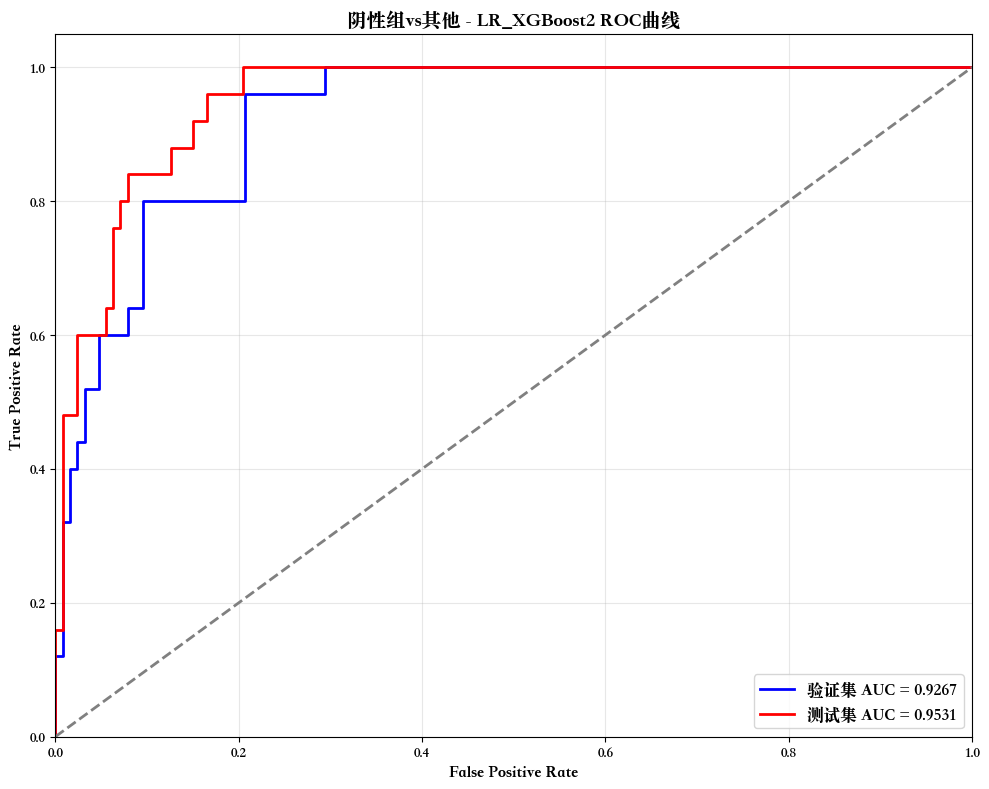


===== SHAP 模型依赖度:  =====


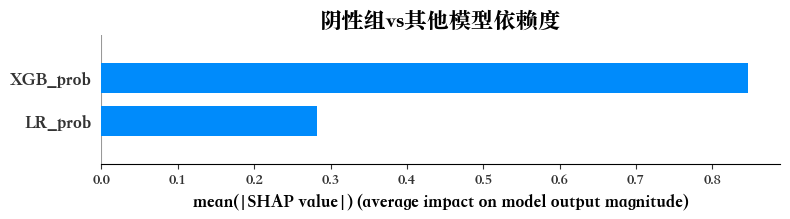

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:26,000] A new study created in memory with name: no-name-351a36d2-cae9-492c-986e-5b41ddcb48db


开始超参数优化...


Best trial: 1. Best value: 0.14501:   4%|▍         | 4/100 [00:00<00:02, 35.06it/s] 

[I 2025-09-29 15:00:26,028] Trial 0 finished with value: 0.14892669262827085 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.14892669262827085.
[I 2025-09-29 15:00:26,058] Trial 1 finished with value: 0.14500990640158506 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.14500990640158506.
[I 2025-09-29 15:00:26,085] Trial 2 finished with value: 0.15098517455762794 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.0327818765339761

...

[I 2025-09-29 15:00:28,958] Trial 82 finished with value: 0.16163387306141974 and parameters: {'n_estimators': 10, 'max_depth': 9, 'learning_rate': 0.09409376853653595, 'subsample': 0.901685855173637, 'colsample_bytree': 0.6030352951037472, 'reg_alpha': 3.3815615494044735, 'reg_lambda': 1.2595823087921907e-07, 'min_child_weight': 3, 'gamma': 4.4919266636060176}. Best is trial 71 with value: 0.138855981416957.
[I 2025-09-29 15:00:28,994] Trial 83 finished with value: 0.1493301222928196 and parameters: {'n_estimators': 40, 'max_depth': 10, 'learning_rate': 0.0702989470357046, 'subsample': 0.8515358962958238, 'colsample_bytree': 0.6627123325974913, 'reg_alpha': 0.0002519207168712372, 'reg_lambda': 3.5136375165939506e-08, 'min_child_weight': 4, 'gamma': 3.9391010093541383}. Best is trial 71 with value: 0.138855981416957.
[I 2025-09-29 15:00:29,026] Trial 84 finished with value: 0.14776422764227648 and parameters: {'n_estimators': 20, 'max_depth': 10, 'learning_rate': 0.10438352129893934, '

Best trial: 71. Best value: 0.138856:  94%|█████████▍| 94/100 [00:03<00:00, 31.36it/s]

[I 2025-09-29 15:00:29,189] Trial 89 finished with value: 0.15186342829814836 and parameters: {'n_estimators': 40, 'max_depth': 10, 'learning_rate': 0.05451429478384813, 'subsample': 0.7515837438521937, 'colsample_bytree': 0.8333493472644046, 'reg_alpha': 9.105875302256631e-06, 'reg_lambda': 9.073695281792726e-07, 'min_child_weight': 3, 'gamma': 3.602202436724417}. Best is trial 71 with value: 0.138855981416957.
[I 2025-09-29 15:00:29,221] Trial 90 finished with value: 0.14351164856186394 and parameters: {'n_estimators': 90, 'max_depth': 3, 'learning_rate': 0.20882019652340358, 'subsample': 0.9138419761507741, 'colsample_bytree': 0.6802868642247214, 'reg_alpha': 0.0004825518585925384, 'reg_lambda': 5.09814957758786e-06, 'min_child_weight': 4, 'gamma': 3.876501831313569}. Best is trial 71 with value: 0.138855981416957.
[I 2025-09-29 15:00:29,257] Trial 91 finished with value: 0.14364897178383562 and parameters: {'n_estimators': 70, 'max_depth': 8, 'learning_rate': 0.14581080737440097, '

Best trial: 71. Best value: 0.138856: 100%|██████████| 100/100 [00:03<00:00, 28.40it/s]


[I 2025-09-29 15:00:29,390] Trial 95 finished with value: 0.1454222176675548 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.17909000257310792, 'subsample': 0.8099183642956722, 'colsample_bytree': 0.8973312359703618, 'reg_alpha': 1.7682181840140023e-05, 'reg_lambda': 4.770085939403404e-07, 'min_child_weight': 6, 'gamma': 4.2862569645223525}. Best is trial 71 with value: 0.138855981416957.
[I 2025-09-29 15:00:29,421] Trial 96 finished with value: 0.1498807815809251 and parameters: {'n_estimators': 50, 'max_depth': 4, 'learning_rate': 0.026287097696717093, 'subsample': 0.9366682231647793, 'colsample_bytree': 0.660426717321773, 'reg_alpha': 3.4554021726734454e-05, 'reg_lambda': 0.0004855235735320692, 'min_child_weight': 4, 'gamma': 4.010322872623032}. Best is trial 71 with value: 0.138855981416957.
[I 2025-09-29 15:00:29,454] Trial 97 finished with value: 0.14439639270342286 and parameters: {'n_estimators': 90, 'max_depth': 7, 'learning_rate': 0.10633211797931844,

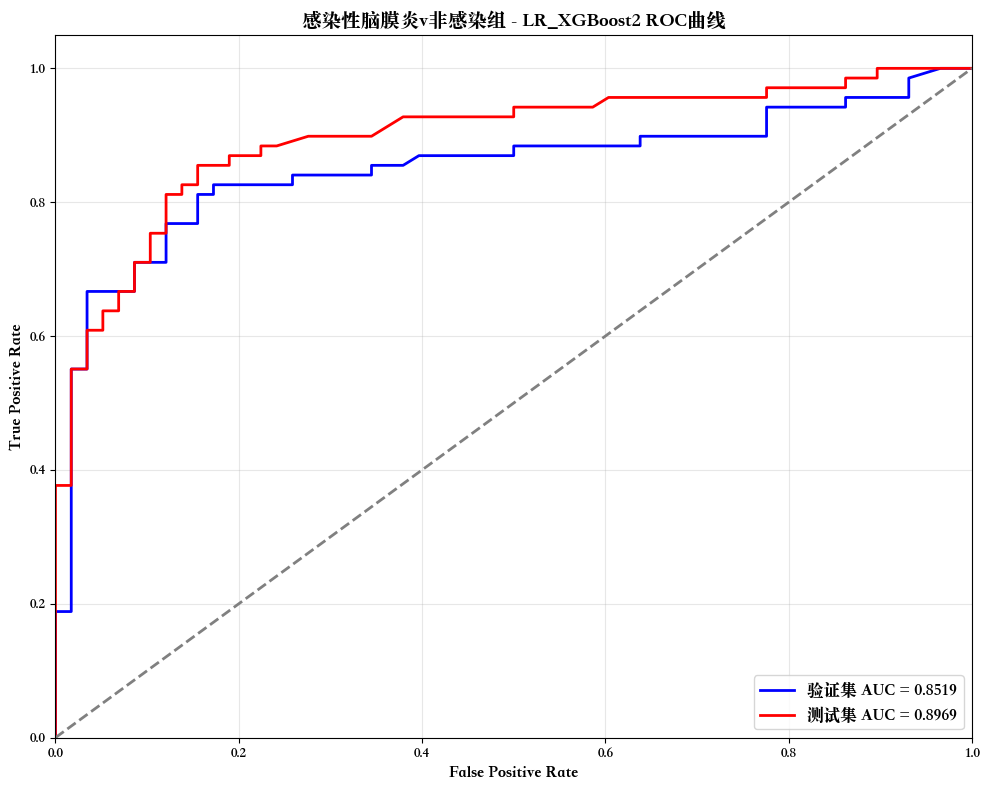


===== SHAP 模型依赖度:  =====


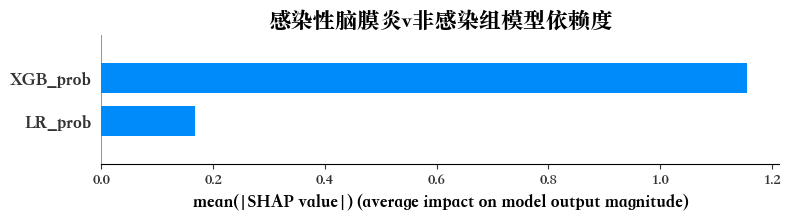

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:30,575] A new study created in memory with name: no-name-ed5776f5-04e5-4d9c-8bbf-4a16cf6b368d


开始超参数优化...


Best trial: 0. Best value: 0.198633:   4%|▍         | 4/100 [00:00<00:02, 34.48it/s]

[I 2025-09-29 15:00:30,603] Trial 0 finished with value: 0.19863286223580334 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.19863286223580334.
[I 2025-09-29 15:00:30,633] Trial 1 finished with value: 0.20208810797046084 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.19863286223580334.
[I 2025-09-29 15:00:30,663] Trial 2 finished with value: 0.20309714795008904 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.0327818765339761

...

[I 2025-09-29 15:00:33,924] Trial 90 finished with value: 0.17746689584924868 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.10390435182013576, 'subsample': 0.7472623848803926, 'colsample_bytree': 0.6012940875080873, 'reg_alpha': 0.00156188559277547, 'reg_lambda': 0.00019890228642882837, 'min_child_weight': 1, 'gamma': 0.7894304208151768}. Best is trial 76 with value: 0.16063152533740754.


Best trial: 93. Best value: 0.148676:  95%|█████████▌| 95/100 [00:03<00:00, 14.84it/s]

[I 2025-09-29 15:00:34,204] Trial 91 finished with value: 0.17202699261522802 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.1215875777151382, 'subsample': 0.7517669966710018, 'colsample_bytree': 0.6841879408040765, 'reg_alpha': 0.001457973084959276, 'reg_lambda': 0.00013888709229609628, 'min_child_weight': 1, 'gamma': 0.7816441426489857}. Best is trial 76 with value: 0.16063152533740754.
[I 2025-09-29 15:00:34,272] Trial 92 finished with value: 0.15914820473643998 and parameters: {'n_estimators': 110, 'max_depth': 10, 'learning_rate': 0.17174958409602198, 'subsample': 0.8079194888195628, 'colsample_bytree': 0.6853539796237598, 'reg_alpha': 0.00017453961216602764, 'reg_lambda': 2.2449972873044198e-05, 'min_child_weight': 1, 'gamma': 1.1513985255310863}. Best is trial 92 with value: 0.15914820473643998.
[I 2025-09-29 15:00:34,337] Trial 93 finished with value: 0.14867583396995165 and parameters: {'n_estimators': 110, 'max_depth': 10, 'learning_rate': 0.2034704

Best trial: 93. Best value: 0.148676: 100%|██████████| 100/100 [00:03<00:00, 25.21it/s]


[I 2025-09-29 15:00:34,438] Trial 96 finished with value: 0.18060224089635857 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.16935859923466326, 'subsample': 0.8276123595966115, 'colsample_bytree': 0.6666098489807958, 'reg_alpha': 2.684963898560345e-05, 'reg_lambda': 2.1965008849391174e-05, 'min_child_weight': 2, 'gamma': 0.9512553437176584}. Best is trial 93 with value: 0.14867583396995165.
[I 2025-09-29 15:00:34,475] Trial 97 finished with value: 0.17552521008403354 and parameters: {'n_estimators': 130, 'max_depth': 10, 'learning_rate': 0.16379378827936927, 'subsample': 0.8806939300620573, 'colsample_bytree': 0.6766803911556943, 'reg_alpha': 6.42432272402602e-05, 'reg_lambda': 4.2129135613921855e-05, 'min_child_weight': 1, 'gamma': 0.6553278073028532}. Best is trial 93 with value: 0.14867583396995165.
[I 2025-09-29 15:00:34,508] Trial 98 finished with value: 0.1807804940157881 and parameters: {'n_estimators': 110, 'max_depth': 9, 'learning_rate': 0.2087603643

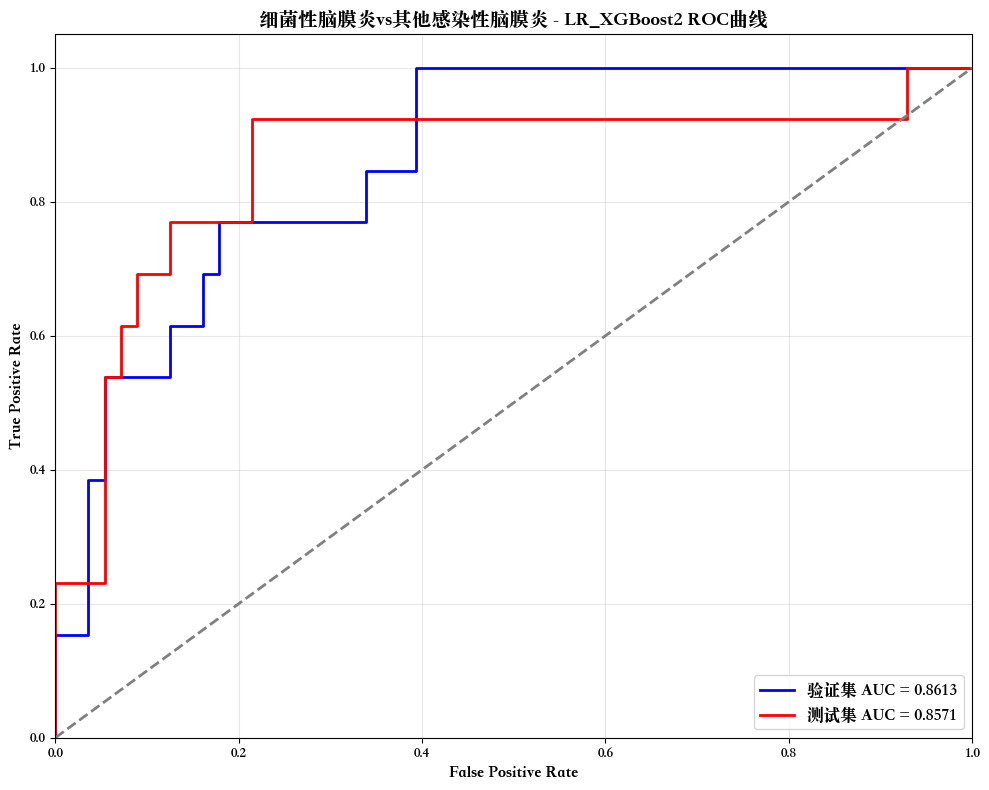


===== SHAP 模型依赖度:  =====


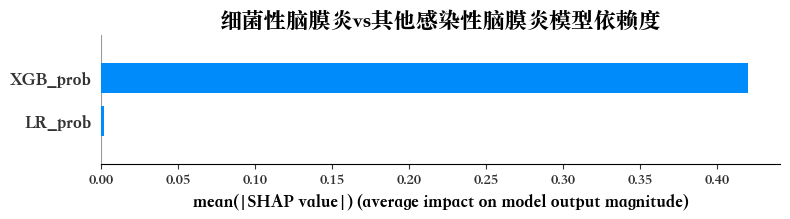

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:35,767] A new study created in memory with name: no-name-854cb9b5-6ec6-4842-b8a5-d5a747fbaa40


开始超参数优化...


Best trial: 1. Best value: 0.161583:   4%|▍         | 4/100 [00:00<00:02, 35.60it/s]

[I 2025-09-29 15:00:35,796] Trial 0 finished with value: 0.16926550461033207 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.16926550461033207.
[I 2025-09-29 15:00:35,824] Trial 1 finished with value: 0.1615826702033598 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.1615826702033598.
[I 2025-09-29 15:00:35,851] Trial 2 finished with value: 0.17878615637236328 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.032781876533976156

...

[I 2025-09-29 15:00:39,166] Trial 84 finished with value: 0.11993810786914239 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.07831300311077394, 'subsample': 0.6908907810644628, 'colsample_bytree': 0.6472312113034622, 'reg_alpha': 1.0299264363348658e-08, 'reg_lambda': 7.37000190602547e-05, 'min_child_weight': 5, 'gamma': 2.3415390893965258}. Best is trial 84 with value: 0.11993810786914239.
[I 2025-09-29 15:00:39,201] Trial 85 finished with value: 0.13171024377920926 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.22809996271687202, 'subsample': 0.6894048482048146, 'colsample_bytree': 0.6513986506574716, 'reg_alpha': 7.027429978258834e-08, 'reg_lambda': 2.5716467947753062e-05, 'min_child_weight': 5, 'gamma': 2.37424117783584}. Best is trial 84 with value: 0.11993810786914239.
[I 2025-09-29 15:00:39,235] Trial 86 finished with value: 0.14036882657572325 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.080491628410

Best trial: 84. Best value: 0.119938:  96%|█████████▌| 96/100 [00:03<00:00, 28.26it/s]

[I 2025-09-29 15:00:39,372] Trial 90 finished with value: 0.13492484526967297 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.11030372766812188, 'subsample': 0.7922160631720001, 'colsample_bytree': 0.6423991500633339, 'reg_alpha': 1.039416781071351e-06, 'reg_lambda': 9.16621910017209e-05, 'min_child_weight': 5, 'gamma': 2.6741935551333986}. Best is trial 84 with value: 0.11993810786914239.
[I 2025-09-29 15:00:39,418] Trial 91 finished with value: 0.1355879752431477 and parameters: {'n_estimators': 190, 'max_depth': 3, 'learning_rate': 0.07273362780440577, 'subsample': 0.6841347633848535, 'colsample_bytree': 0.6588366777613179, 'reg_alpha': 1.441787528371439e-07, 'reg_lambda': 4.22548980243882e-05, 'min_child_weight': 5, 'gamma': 3.129846723952854}. Best is trial 84 with value: 0.11993810786914239.
[I 2025-09-29 15:00:39,450] Trial 92 finished with value: 0.12887457370215993 and parameters: {'n_estimators': 160, 'max_depth': 2, 'learning_rate': 0.100838195710330

Best trial: 84. Best value: 0.119938: 100%|██████████| 100/100 [00:03<00:00, 25.49it/s]


[I 2025-09-29 15:00:39,585] Trial 96 finished with value: 0.1543387646835923 and parameters: {'n_estimators': 190, 'max_depth': 2, 'learning_rate': 0.13521576778006714, 'subsample': 0.6504012975657837, 'colsample_bytree': 0.6044458157501876, 'reg_alpha': 1.8625722266666884e-06, 'reg_lambda': 1.4063850787328448e-05, 'min_child_weight': 7, 'gamma': 1.9577451523081715}. Best is trial 84 with value: 0.11993810786914239.
[I 2025-09-29 15:00:39,622] Trial 97 finished with value: 0.1375836806871289 and parameters: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.19024218943984936, 'subsample': 0.6343219863118532, 'colsample_bytree': 0.6249815828859959, 'reg_alpha': 2.869256285722909e-08, 'reg_lambda': 8.770742732639471e-05, 'min_child_weight': 5, 'gamma': 2.6420621800298854}. Best is trial 84 with value: 0.11993810786914239.
[I 2025-09-29 15:00:39,657] Trial 98 finished with value: 0.16829607174434746 and parameters: {'n_estimators': 160, 'max_depth': 2, 'learning_rate': 0.00195520221

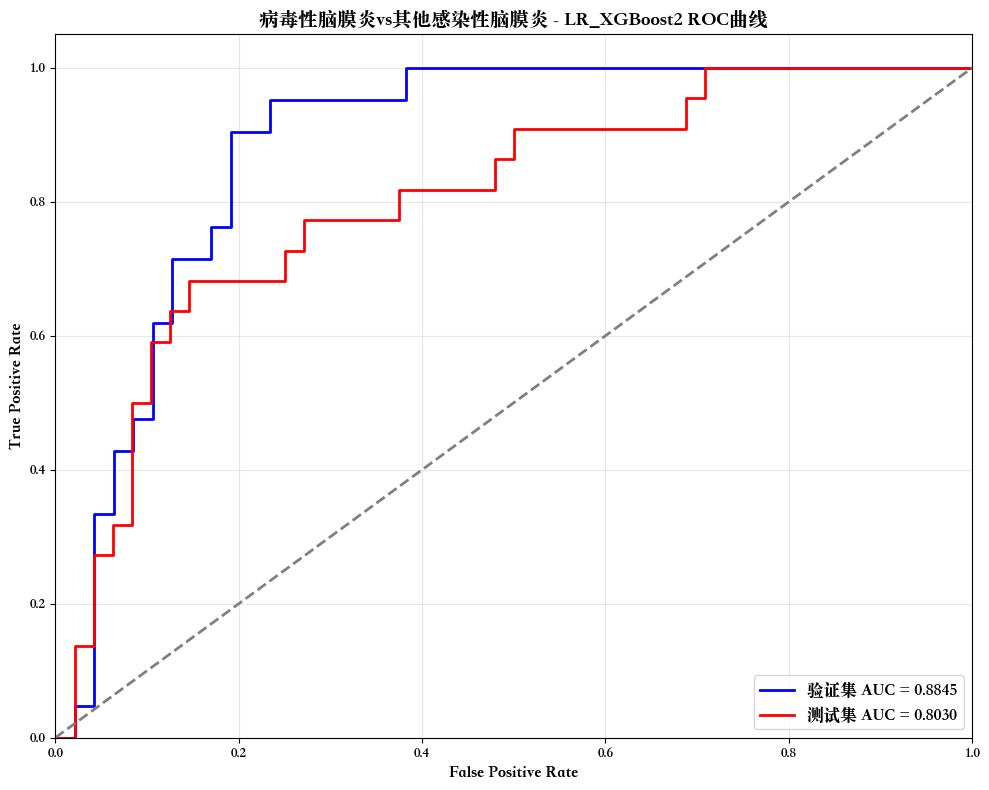


===== SHAP 模型依赖度:  =====


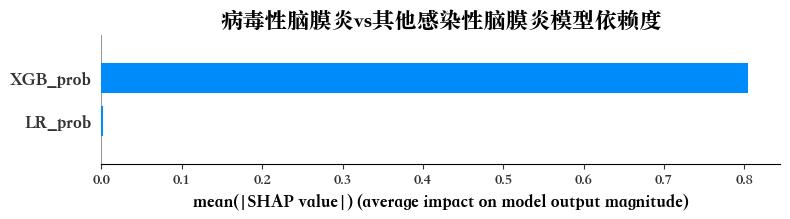

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:41,097] A new study created in memory with name: no-name-d1f88272-ab38-4a2a-8247-71b7a956d08a


开始超参数优化...


Best trial: 1. Best value: 0.105115:   4%|▍         | 4/100 [00:00<00:02, 35.50it/s]

[I 2025-09-29 15:00:41,123] Trial 0 finished with value: 0.160461229946524 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.160461229946524.
[I 2025-09-29 15:00:41,152] Trial 1 finished with value: 0.10511522790934558 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.10511522790934558.
[I 2025-09-29 15:00:41,180] Trial 2 finished with value: 0.1958030939648585 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.032781876533976156, '

...

[I 2025-09-29 15:00:44,598] Trial 89 finished with value: 0.08276674306086063 and parameters: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1195031955455678, 'subsample': 0.7956296876588048, 'colsample_bytree': 0.8844973778537338, 'reg_alpha': 0.000619718140891956, 'reg_lambda': 0.011470380974279874, 'min_child_weight': 4, 'gamma': 0.1372986604885813}. Best is trial 83 with value: 0.07871466768525592.
[I 2025-09-29 15:00:44,647] Trial 90 finished with value: 0.11419340463458094 and parameters: {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.014475296613445147, 'subsample': 0.7704927791234936, 'colsample_bytree': 0.6016695761919466, 'reg_alpha': 1.573611410475515e-08, 'reg_lambda': 0.07217022334431522, 'min_child_weight': 5, 'gamma': 1.024632779927701}. Best is trial 83 with value: 0.07871466768525592.
[I 2025-09-29 15:00:44,692] Trial 91 finished with value: 0.07752100840336129 and parameters: {'n_estimators': 190, 'max_depth': 4, 'learning_rate': 0.2141573216869239

Best trial: 92. Best value: 0.0748663:  99%|█████████▉| 99/100 [00:03<00:00, 21.81it/s]

[I 2025-09-29 15:00:44,818] Trial 94 finished with value: 0.07709447415329773 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.20353386879743973, 'subsample': 0.7540822217630442, 'colsample_bytree': 0.9522850198114997, 'reg_alpha': 1.0347201573139232e-08, 'reg_lambda': 1.0113560505912476e-06, 'min_child_weight': 5, 'gamma': 1.7118244811544931}. Best is trial 92 with value: 0.07486631016042777.
[I 2025-09-29 15:00:44,863] Trial 95 finished with value: 0.08500127323656737 and parameters: {'n_estimators': 170, 'max_depth': 4, 'learning_rate': 0.2096105470357696, 'subsample': 0.7577654022151594, 'colsample_bytree': 0.9526510330632595, 'reg_alpha': 1.2143389026576059e-08, 'reg_lambda': 9.687148568884158e-07, 'min_child_weight': 5, 'gamma': 1.6743610417868455}. Best is trial 92 with value: 0.07486631016042777.
[I 2025-09-29 15:00:44,910] Trial 96 finished with value: 0.0891583906289789 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.2552385244

Best trial: 92. Best value: 0.0748663: 100%|██████████| 100/100 [00:03<00:00, 25.14it/s]


[I 2025-09-29 15:00:45,074] Trial 99 finished with value: 0.08632225617519729 and parameters: {'n_estimators': 160, 'max_depth': 5, 'learning_rate': 0.16277913155622722, 'subsample': 0.7389558066001047, 'colsample_bytree': 0.9743883101887462, 'reg_alpha': 1.8335469166068183e-08, 'reg_lambda': 6.040667361719452e-06, 'min_child_weight': 5, 'gamma': 1.5719689494142495}. Best is trial 92 with value: 0.07486631016042777.

优化完成!
Number of finished trials:  100
Best trial:
  Best AUC: 0.9251
  Best params: 
    n_estimators: 170
    max_depth: 4
    learning_rate: 0.2018255060275148
    subsample: 0.7540141984622278
    colsample_bytree: 0.9563082467661499
    reg_alpha: 1.0604428524331802e-08
    reg_lambda: 8.872983785189323e-07
    min_child_weight: 5
    gamma: 1.7134202196261161

使用最佳参数训练最终模型...
预处理管道构建完成
开始超参数优化...
Fitting 5 folds for each of 48 candidates, totalling 240 fits

优化完成!
最佳参数: {'classifier__C': 0.01, 'classifier__class_weight': 'balanced', 'classifier__penalty': 'l2', 'class

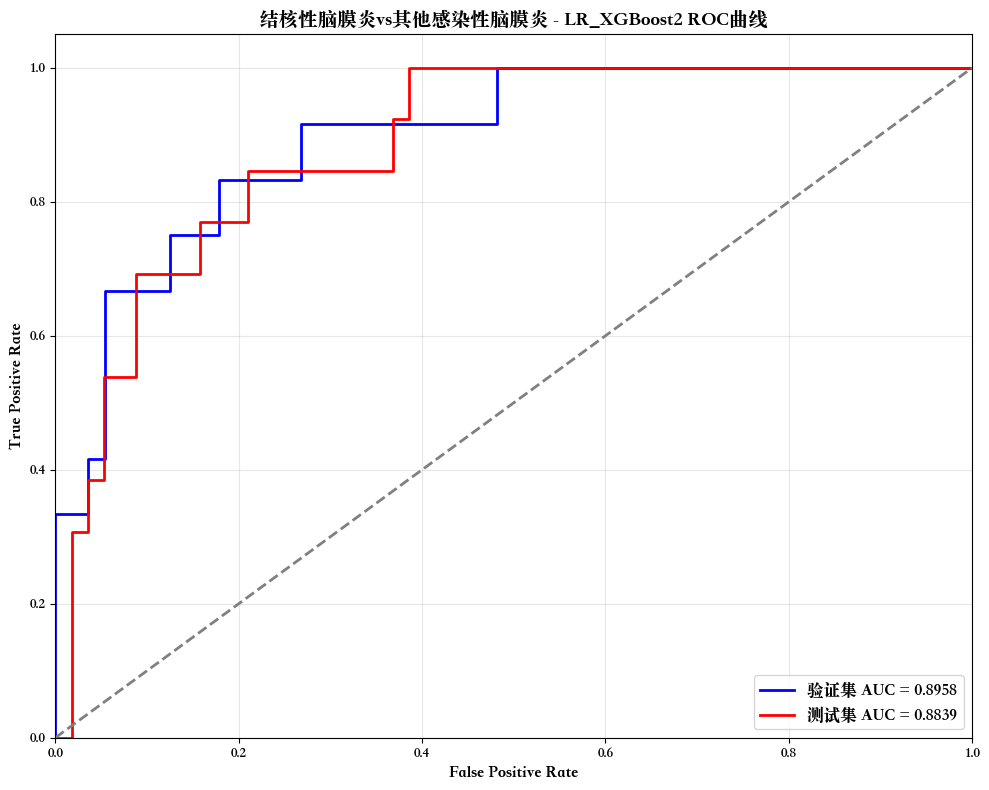


===== SHAP 模型依赖度:  =====


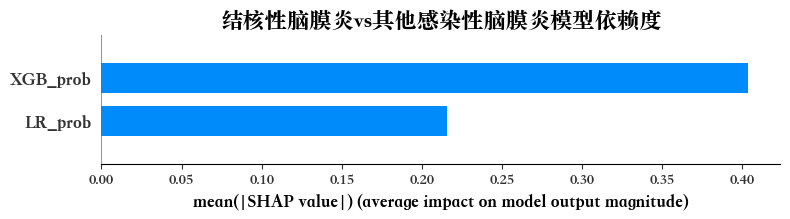

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:46,438] A new study created in memory with name: no-name-06b135b8-b0c6-4de8-b94e-cab5ca0a82fc


开始超参数优化...


Best trial: 1. Best value: 0.154853:   1%|          | 1/100 [00:00<00:08, 12.22it/s]

[I 2025-09-29 15:00:46,485] Trial 0 finished with value: 0.1857651607651608 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.1857651607651608.
[I 2025-09-29 15:00:46,518] Trial 1 finished with value: 0.15485347985347975 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.15485347985347975.


...

[I 2025-09-29 15:00:49,838] Trial 83 finished with value: 0.14472934472934473 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.01901721940614473, 'subsample': 0.6387135231217329, 'colsample_bytree': 0.8829059637557327, 'reg_alpha': 8.756678818403174e-05, 'reg_lambda': 7.582545743731776e-07, 'min_child_weight': 2, 'gamma': 4.757503238273233}. Best is trial 83 with value: 0.14472934472934473.
[I 2025-09-29 15:00:49,873] Trial 84 finished with value: 0.1556267806267806 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.010246301516781527, 'subsample': 0.6363984254192073, 'colsample_bytree': 0.8692271287450732, 'reg_alpha': 9.57974257807511e-05, 'reg_lambda': 7.812803141659131e-05, 'min_child_weight': 2, 'gamma': 4.820623621605091}. Best is trial 83 with value: 0.14472934472934473.
[I 2025-09-29 15:00:49,906] Trial 85 finished with value: 0.152024827024827 and parameters: {'n_estimators': 170, 'max_depth': 2, 'learning_rate': 0.0126372745304840

Best trial: 83. Best value: 0.144729:  96%|█████████▌| 96/100 [00:03<00:00, 29.61it/s]

[I 2025-09-29 15:00:50,063] Trial 90 finished with value: 0.16002238502238497 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.006395320466283192, 'subsample': 0.6118062130580627, 'colsample_bytree': 0.8308501583089235, 'reg_alpha': 0.004718313661609141, 'reg_lambda': 1.6311499597623585e-06, 'min_child_weight': 2, 'gamma': 4.198978349570666}. Best is trial 83 with value: 0.14472934472934473.
[I 2025-09-29 15:00:50,098] Trial 91 finished with value: 0.15310337810337804 and parameters: {'n_estimators': 170, 'max_depth': 3, 'learning_rate': 0.019707838685611025, 'subsample': 0.6602876820605075, 'colsample_bytree': 0.878390750041687, 'reg_alpha': 1.4683251303433348e-08, 'reg_lambda': 3.096878315686379e-08, 'min_child_weight': 3, 'gamma': 4.478728869976718}. Best is trial 83 with value: 0.14472934472934473.
[I 2025-09-29 15:00:50,134] Trial 92 finished with value: 0.15950345950345957 and parameters: {'n_estimators': 170, 'max_depth': 3, 'learning_rate': 0.01775377920

Best trial: 83. Best value: 0.144729: 100%|██████████| 100/100 [00:03<00:00, 25.39it/s]


[I 2025-09-29 15:00:50,272] Trial 96 finished with value: 0.1507020757020756 and parameters: {'n_estimators': 170, 'max_depth': 4, 'learning_rate': 0.028469222896817425, 'subsample': 0.6332716762612485, 'colsample_bytree': 0.9030443463682698, 'reg_alpha': 0.00029833339377452207, 'reg_lambda': 0.00018908548593091174, 'min_child_weight': 2, 'gamma': 4.576470789469972}. Best is trial 83 with value: 0.14472934472934473.
[I 2025-09-29 15:00:50,308] Trial 97 finished with value: 0.14809727309727305 and parameters: {'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.009948109514803783, 'subsample': 0.6656059255749711, 'colsample_bytree': 0.8697779873028062, 'reg_alpha': 0.001572449629546937, 'reg_lambda': 7.158390224024156e-07, 'min_child_weight': 1, 'gamma': 2.8994989849666872}. Best is trial 83 with value: 0.14472934472934473.
[I 2025-09-29 15:00:50,342] Trial 98 finished with value: 0.15307285307285312 and parameters: {'n_estimators': 140, 'max_depth': 6, 'learning_rate': 0.0104078254

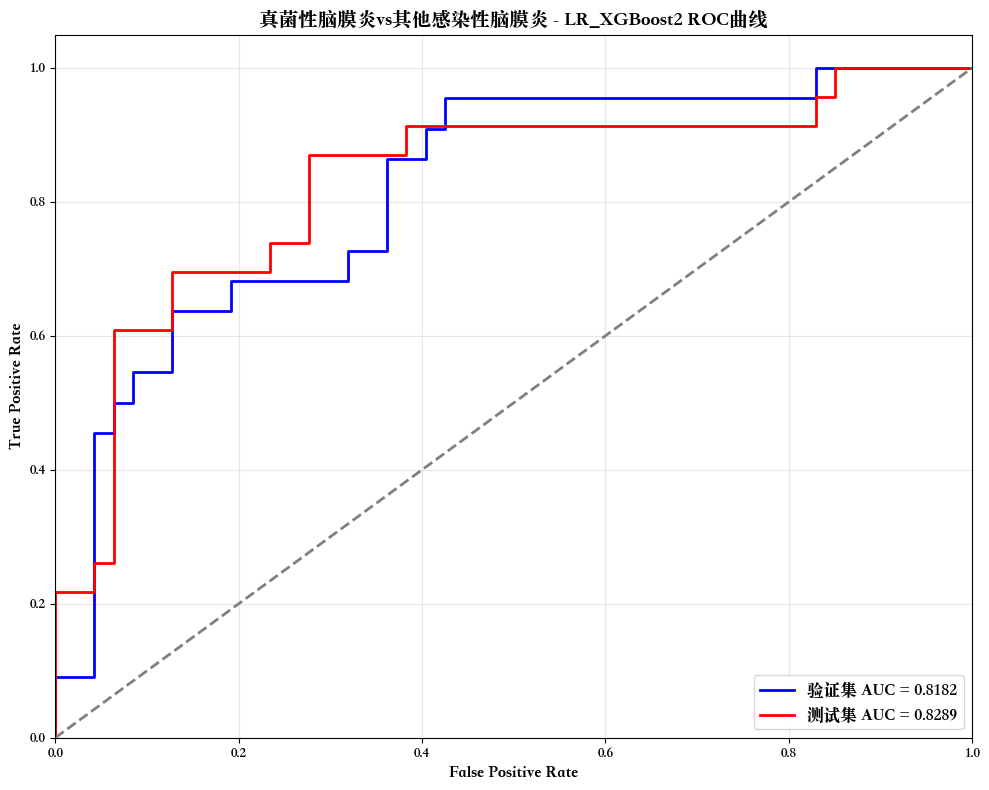


===== SHAP 模型依赖度:  =====


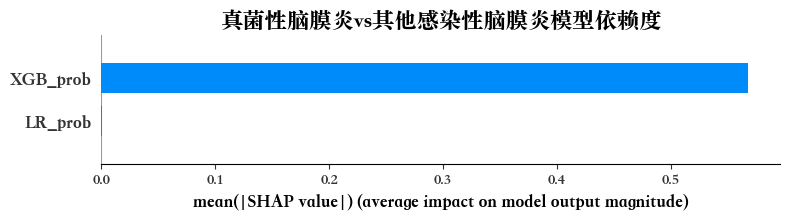

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:51,708] A new study created in memory with name: no-name-0087ef6c-fb82-4952-8068-668fb23c71d9


开始超参数优化...


Best trial: 0. Best value: 0.0847516:   4%|▍         | 4/100 [00:00<00:02, 35.26it/s]

[I 2025-09-29 15:00:51,737] Trial 0 finished with value: 0.08475156932382288 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.08475156932382288.
[I 2025-09-29 15:00:51,766] Trial 1 finished with value: 0.08503105072571915 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.08475156932382288.
[I 2025-09-29 15:00:51,794] Trial 2 finished with value: 0.08869378040409459 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.0327818765339761

...

[I 2025-09-29 15:00:54,993] Trial 83 finished with value: 0.07699945782473316 and parameters: {'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.02817896586936613, 'subsample': 0.8104787997277306, 'colsample_bytree': 0.7809772616497361, 'reg_alpha': 0.00022696795123370689, 'reg_lambda': 1.2306017436913707e-06, 'min_child_weight': 6, 'gamma': 0.4626145471274996}. Best is trial 81 with value: 0.07512024850528753.
[I 2025-09-29 15:00:55,028] Trial 84 finished with value: 0.07523403070005263 and parameters: {'n_estimators': 160, 'max_depth': 3, 'learning_rate': 0.0422537406283581, 'subsample': 0.8305267208957896, 'colsample_bytree': 0.765564369206506, 'reg_alpha': 0.0009028541115034073, 'reg_lambda': 4.4717170313963245e-06, 'min_child_weight': 6, 'gamma': 0.6155627161735235}. Best is trial 81 with value: 0.07512024850528753.
[I 2025-09-29 15:00:55,062] Trial 85 finished with value: 0.07763066921339823 and parameters: {'n_estimators': 170, 'max_depth': 3, 'learning_rate': 0.0474104884

Best trial: 93. Best value: 0.0729651:  95%|█████████▌| 95/100 [00:03<00:00, 28.83it/s]

[I 2025-09-29 15:00:55,233] Trial 90 finished with value: 0.07391415724077555 and parameters: {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.042529705178576974, 'subsample': 0.812853176894925, 'colsample_bytree': 0.7702737571966245, 'reg_alpha': 0.0003838110842167222, 'reg_lambda': 7.101829931147755e-08, 'min_child_weight': 5, 'gamma': 0.5688889078789386}. Best is trial 90 with value: 0.07391415724077555.
[I 2025-09-29 15:00:55,268] Trial 91 finished with value: 0.07437973159837252 and parameters: {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.043655434145565435, 'subsample': 0.813581619164474, 'colsample_bytree': 0.7703612858287088, 'reg_alpha': 0.0003261211882305271, 'reg_lambda': 5.82242204483446e-08, 'min_child_weight': 5, 'gamma': 0.5539652990551333}. Best is trial 90 with value: 0.07391415724077555.
[I 2025-09-29 15:00:55,303] Trial 92 finished with value: 0.0744044776713324 and parameters: {'n_estimators': 180, 'max_depth': 3, 'learning_rate': 0.0439316572258

Best trial: 96. Best value: 0.0713672: 100%|██████████| 100/100 [00:03<00:00, 25.95it/s]


[I 2025-09-29 15:00:55,440] Trial 96 finished with value: 0.0713671770077895 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.05114491317971572, 'subsample': 0.7720193861401283, 'colsample_bytree': 0.7927320313682283, 'reg_alpha': 0.0016003399216033933, 'reg_lambda': 1.4600446330152173e-08, 'min_child_weight': 5, 'gamma': 0.8164240875330018}. Best is trial 96 with value: 0.0713671770077895.
[I 2025-09-29 15:00:55,484] Trial 97 finished with value: 0.07679925090279638 and parameters: {'n_estimators': 200, 'max_depth': 2, 'learning_rate': 0.051448176412157334, 'subsample': 0.7651640413169569, 'colsample_bytree': 0.8279116905647778, 'reg_alpha': 0.008179682523029369, 'reg_lambda': 1.895259039335631e-08, 'min_child_weight': 4, 'gamma': 0.8148125078594177}. Best is trial 96 with value: 0.0713671770077895.
[I 2025-09-29 15:00:55,518] Trial 98 finished with value: 0.0744487470279841 and parameters: {'n_estimators': 180, 'max_depth': 2, 'learning_rate': 0.04548982103991

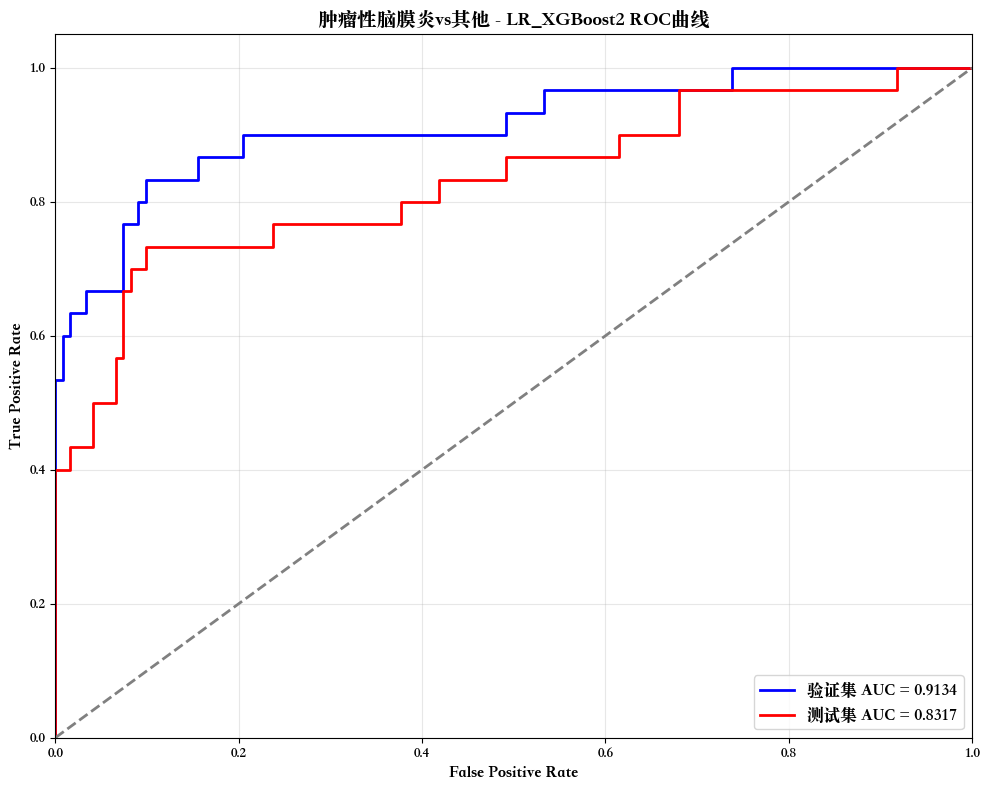


===== SHAP 模型依赖度:  =====


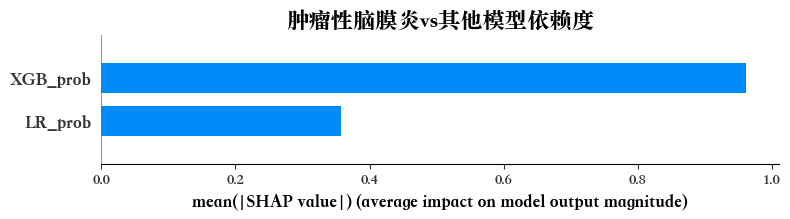

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:00:57,124] A new study created in memory with name: no-name-fbc5a9ff-d5d4-4fff-81f1-d798f746bf6b


开始超参数优化...


Best trial: 0. Best value: 0.173162:   4%|▍         | 4/100 [00:00<00:02, 32.53it/s]

[I 2025-09-29 15:00:57,162] Trial 0 finished with value: 0.17316244528170388 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.17316244528170388.
[I 2025-09-29 15:00:57,191] Trial 1 finished with value: 0.18602056427902536 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 0 with value: 0.17316244528170388.
[I 2025-09-29 15:00:57,218] Trial 2 finished with value: 0.1734736045473355 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.03278187653397615

...

[I 2025-09-29 15:01:01,190] Trial 92 finished with value: 0.1520459470348673 and parameters: {'n_estimators': 180, 'max_depth': 5, 'learning_rate': 0.04650752635718405, 'subsample': 0.6387122746923412, 'colsample_bytree': 0.660363592518146, 'reg_alpha': 0.0004123272936617613, 'reg_lambda': 2.0295174729053096e-08, 'min_child_weight': 1, 'gamma': 0.37520592574008427}. Best is trial 38 with value: 0.14284946207287064.


Best trial: 38. Best value: 0.142849:  96%|█████████▌| 96/100 [00:04<00:00, 11.27it/s]

[I 2025-09-29 15:01:01,468] Trial 93 finished with value: 0.15545168456127367 and parameters: {'n_estimators': 160, 'max_depth': 5, 'learning_rate': 0.061939573341084006, 'subsample': 0.6376078186769056, 'colsample_bytree': 0.6567522053206659, 'reg_alpha': 0.005571243236288436, 'reg_lambda': 2.274287874289761e-08, 'min_child_weight': 1, 'gamma': 0.12483929705944985}. Best is trial 38 with value: 0.14284946207287064.
[I 2025-09-29 15:01:01,524] Trial 94 finished with value: 0.15685911536032404 and parameters: {'n_estimators': 160, 'max_depth': 5, 'learning_rate': 0.04766239493234965, 'subsample': 0.6359904166057222, 'colsample_bytree': 0.670647294092847, 'reg_alpha': 0.00056345444682832, 'reg_lambda': 2.2541204202198407e-08, 'min_child_weight': 1, 'gamma': 0.1333111913609772}. Best is trial 38 with value: 0.14284946207287064.
[I 2025-09-29 15:01:01,570] Trial 95 finished with value: 0.16433986867608952 and parameters: {'n_estimators': 140, 'max_depth': 5, 'learning_rate': 0.165553856781

Best trial: 38. Best value: 0.142849: 100%|██████████| 100/100 [00:04<00:00, 21.53it/s]


[I 2025-09-29 15:01:01,676] Trial 97 finished with value: 0.1529098699827951 and parameters: {'n_estimators': 100, 'max_depth': 6, 'learning_rate': 0.0396980141992289, 'subsample': 0.600332662728502, 'colsample_bytree': 0.7521663898653672, 'reg_alpha': 0.013340061709382895, 'reg_lambda': 6.310348043985049e-08, 'min_child_weight': 1, 'gamma': 0.33089988350069943}. Best is trial 38 with value: 0.14284946207287064.
[I 2025-09-29 15:01:01,722] Trial 98 finished with value: 0.16631626086199014 and parameters: {'n_estimators': 90, 'max_depth': 6, 'learning_rate': 0.020486771820449272, 'subsample': 0.60128187149897, 'colsample_bytree': 0.7615698231674675, 'reg_alpha': 2.406557421141118e-05, 'reg_lambda': 5.059224155866837e-08, 'min_child_weight': 2, 'gamma': 0.30540381981412934}. Best is trial 38 with value: 0.14284946207287064.
[I 2025-09-29 15:01:01,767] Trial 99 finished with value: 0.1475412156717557 and parameters: {'n_estimators': 90, 'max_depth': 6, 'learning_rate': 0.02667970833429795

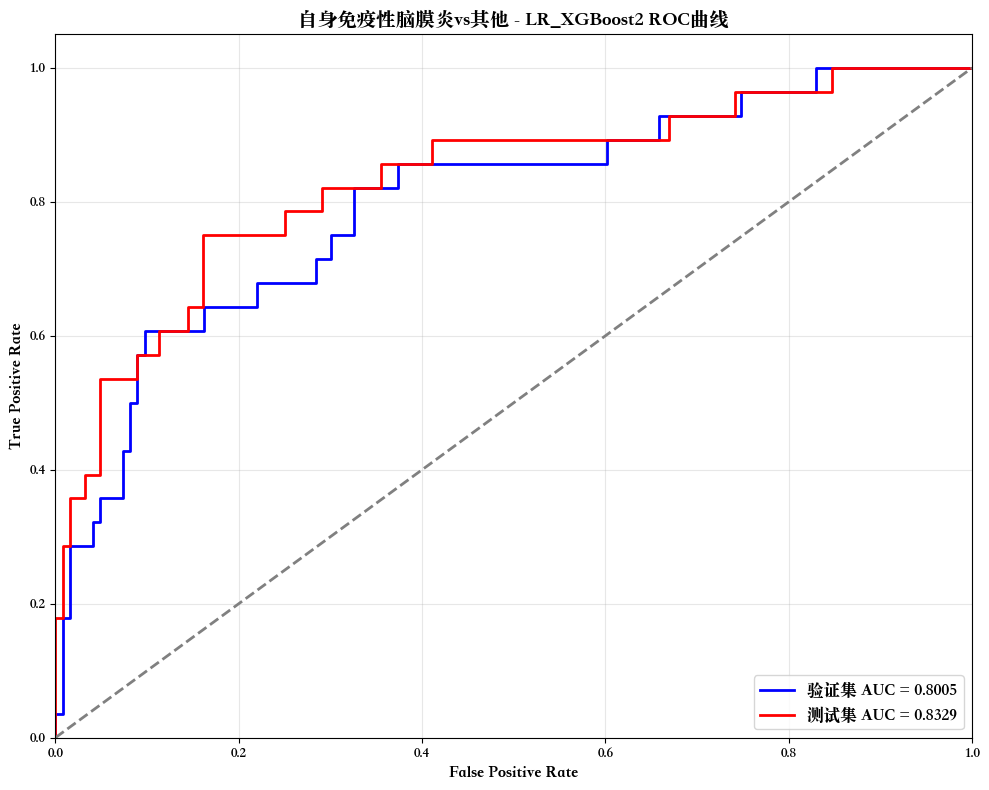


===== SHAP 模型依赖度:  =====


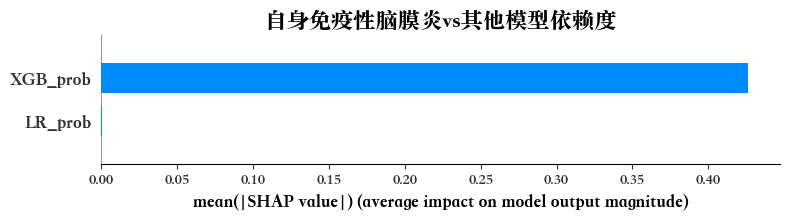

<Figure size 640x480 with 0 Axes>

[I 2025-09-29 15:01:03,187] A new study created in memory with name: no-name-c7c7c3d1-51c9-44dc-ac98-e573c3602e61


开始超参数优化...


Best trial: 1. Best value: 0.136595:   4%|▍         | 4/100 [00:00<00:02, 36.44it/s]

[I 2025-09-29 15:01:03,215] Trial 0 finished with value: 0.16778044871794862 and parameters: {'n_estimators': 80, 'max_depth': 10, 'learning_rate': 0.06504856968981275, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'reg_alpha': 2.5348407664333426e-07, 'reg_lambda': 3.3323645788192616e-08, 'min_child_weight': 9, 'gamma': 3.005575058716044}. Best is trial 0 with value: 0.16778044871794862.
[I 2025-09-29 15:01:03,243] Trial 1 finished with value: 0.13659455128205134 and parameters: {'n_estimators': 150, 'max_depth': 2, 'learning_rate': 0.2526878207508456, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'reg_alpha': 4.329370014459266e-07, 'reg_lambda': 4.4734294104626844e-07, 'min_child_weight': 4, 'gamma': 2.6237821581611893}. Best is trial 1 with value: 0.13659455128205134.
[I 2025-09-29 15:01:03,268] Trial 2 finished with value: 0.16677884615384608 and parameters: {'n_estimators': 90, 'max_depth': 4, 'learning_rate': 0.0327818765339761

...

[I 2025-09-29 15:01:06,192] Trial 89 finished with value: 0.13404647435897432 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05372253563205345, 'subsample': 0.6923206562157977, 'colsample_bytree': 0.6643513853853839, 'reg_alpha': 0.00021784833352455002, 'reg_lambda': 2.9759454326752668e-06, 'min_child_weight': 1, 'gamma': 0.942330384796097}. Best is trial 89 with value: 0.13404647435897432.
[I 2025-09-29 15:01:06,224] Trial 90 finished with value: 0.15055288461538452 and parameters: {'n_estimators': 30, 'max_depth': 3, 'learning_rate': 0.05406003829527439, 'subsample': 0.6885511491898316, 'colsample_bytree': 0.6680585408439915, 'reg_alpha': 0.0008951647111475571, 'reg_lambda': 2.979959040954388e-06, 'min_child_weight': 1, 'gamma': 0.9604149290671025}. Best is trial 89 with value: 0.13404647435897432.
[I 2025-09-29 15:01:06,257] Trial 91 finished with value: 0.14233173076923078 and parameters: {'n_estimators': 50, 'max_depth': 2, 'learning_rate': 0.0406405247842

Best trial: 89. Best value: 0.134046:  95%|█████████▌| 95/100 [00:03<00:00, 29.84it/s]

[I 2025-09-29 15:01:06,357] Trial 94 finished with value: 0.14326121794871793 and parameters: {'n_estimators': 60, 'max_depth': 2, 'learning_rate': 0.04330703303321224, 'subsample': 0.7373147633532687, 'colsample_bytree': 0.6237366050443406, 'reg_alpha': 0.00968383520955486, 'reg_lambda': 1.2604137118188214e-06, 'min_child_weight': 1, 'gamma': 0.40064315333071876}. Best is trial 89 with value: 0.13404647435897432.
[I 2025-09-29 15:01:06,388] Trial 95 finished with value: 0.15723557692307677 and parameters: {'n_estimators': 40, 'max_depth': 8, 'learning_rate': 0.012596514905586607, 'subsample': 0.6463873676414726, 'colsample_bytree': 0.6498835422783229, 'reg_alpha': 0.0002513611359097223, 'reg_lambda': 2.286454895700504e-06, 'min_child_weight': 2, 'gamma': 0.07214193419117132}. Best is trial 89 with value: 0.13404647435897432.


Best trial: 89. Best value: 0.134046: 100%|██████████| 100/100 [00:03<00:00, 29.96it/s]


[I 2025-09-29 15:01:06,423] Trial 96 finished with value: 0.14354967948717956 and parameters: {'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.059763943917513926, 'subsample': 0.6012517078385946, 'colsample_bytree': 0.6593234884481936, 'reg_alpha': 0.00013720994591661758, 'reg_lambda': 4.473399600708194e-07, 'min_child_weight': 2, 'gamma': 0.666841619413006}. Best is trial 89 with value: 0.13404647435897432.
[I 2025-09-29 15:01:06,457] Trial 97 finished with value: 0.16558493589743595 and parameters: {'n_estimators': 70, 'max_depth': 2, 'learning_rate': 0.0034704919662755253, 'subsample': 0.6612393974647258, 'colsample_bytree': 0.6730369923843944, 'reg_alpha': 0.02503861201186652, 'reg_lambda': 4.657274176785828e-06, 'min_child_weight': 1, 'gamma': 0.833418840527013}. Best is trial 89 with value: 0.13404647435897432.
[I 2025-09-29 15:01:06,490] Trial 98 finished with value: 0.15862179487179484 and parameters: {'n_estimators': 40, 'max_depth': 3, 'learning_rate': 0.00997022389991

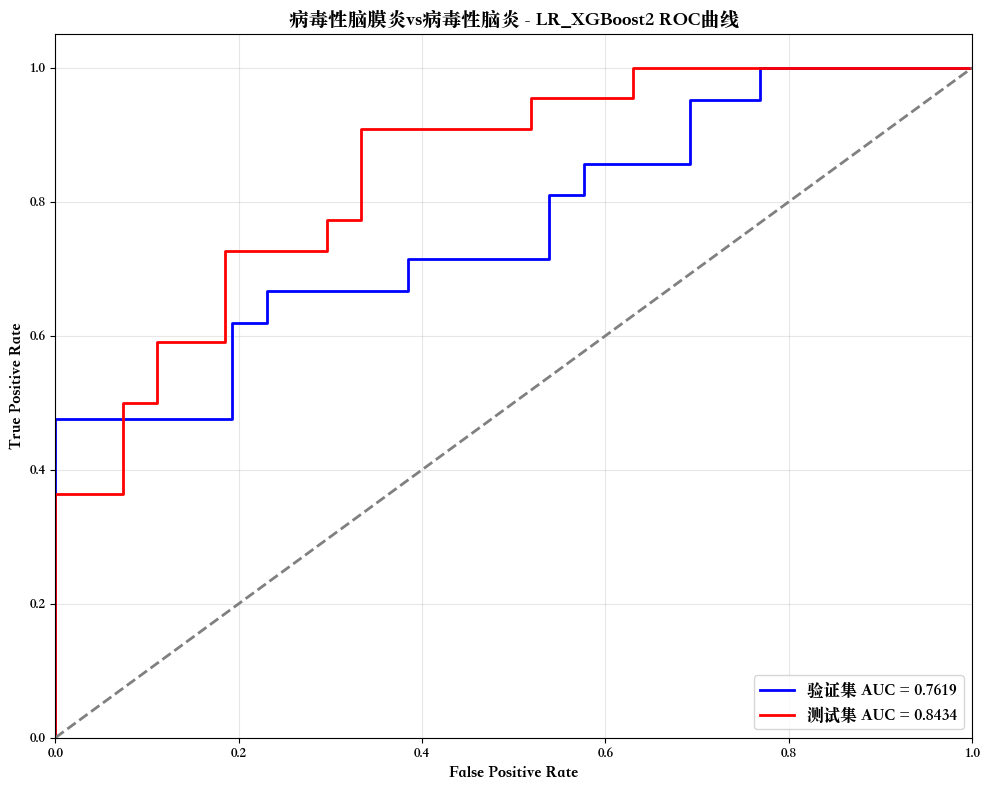


===== SHAP 模型依赖度:  =====


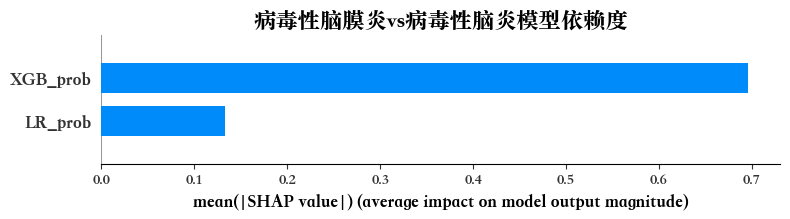

<Figure size 640x480 with 0 Axes>

In [ ]:


screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

def delete_same_col(df):
    same_cols = df.nunique() == 1
    d = dict(same_cols)
    none_feature = []
    for keys, items in d.items():
        if items == True:
            none_feature.append(keys)
    return df.drop(none_feature, axis=1)


def run_model(key, item, selected_df, current_dataset):
    # 筛选需要的组别
    selected_df = selected_df[selected_df['分组'].isin(item[0])]

    # 删除数值一样的列
    selected_df = delete_same_col(selected_df)

    # 选择特征 将数据正例和反例平均分配
    filter_1 = selected_df[selected_df["分组"].isin(item[1])]
    filter_2 = selected_df[selected_df["分组"].isin(item[2])]
    
    X_1 = filter_1[list(filter_1.columns)[:-2]]
    X_2 = filter_2[list(filter_2.columns)[:-2]]

    # X_1 = delete_same_col(X_1)
    # X_2 = delete_same_col(X_2)

    # print(X_1.columns)
    # 标签（分组，1 类与其他类）
    y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
    y_2 = (filter_2['分组'].isin(item[1])).astype(int) 

    # 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
    X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
    X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

    X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
    X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

    # 将正例与反例拼接
    X_train = pd.concat([X_train_1,X_train_2])
    y_train = pd.concat([y_train_1,y_train_2])

    X_val = pd.concat([X_val_1,X_val_2])
    y_val = pd.concat([y_val_1,y_val_2])

    X_test = pd.concat([X_test_1,X_test_2])
    y_test = pd.concat([y_test_1,y_test_2])

    # 得到XGBoost最优模型
    XGBoost_final_model = XGBoost_train(X_train, y_train, X_val, y_val, key)


    # 得到LR最优模型
    LR_final_model = create_pipeline(X_train, y_train)

    # 评估验证集和测试集
    # LR_val_results = evaluate_model(LR_final_model, X_val, y_val, "验证", key)
    # LR_test_results = evaluate_model(LR_final_model, X_test, y_test, "测试", key)    
    final_val_results = mix_model(XGBoost_final_model, LR_final_model, X_train, y_train, X_val, y_val, '验证')
    final_test_results = mix_model(XGBoost_final_model, LR_final_model, X_train, y_train, X_test, y_test, '测试')

    # 绘制ROC——AUC图 并存储数据
    draw_result(y_val, y_test, final_val_results, final_test_results, key, current_dataset)

    # 绘制shap图（对于两个模型的依赖）
    depned_on(XGBoost_final_model, LR_final_model, X_test, final_test_results['mixed_model'], final_test_results['test_preds'], current_dataset, key)
    # draw_shap(final_model, X_train, X_test, current_dataset, key)
    return final_test_results

    
if extract_integers(data_path)[-1] == 2:
    # print(filtered_df.columns)
    selected_features = {
        '阴性组vs其他': filtered_df[['脑脊液_有核细胞计数_定量', '脑脊液_葡萄糖_定量','血_嗜酸性粒细胞百分比_定量','血_葡萄糖空腹_定量','血_结核感染T细胞检测_定性','血_乙型肝炎病毒核心抗体.IgM_定量', '分组', '组名']],
        '感染性脑膜炎v非感染组': filtered_df[['脑脊液_单个核细胞百分比_定量','脑脊液_葡萄糖_定量', '脑脊液_激活淋巴细胞_定量','脑脊液_多个核细胞百分比_定量', '分组', '组名']],
        '细菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']],
        '病毒性脑膜炎vs其他感染性脑膜炎': filtered_df[['脑脊液_葡萄糖_定量','脑脊液_中性粒细胞百分比_定量','血_肌酸激酶_定量', '血_肾小球滤过率_定量', '血_免疫球蛋白E_定量','血_细胞.CD3-CD16+CD56+百分比_定量','脑脊液_多个核细胞百分比_定量','脑脊液_蛋白定量_定量','分组', '组名']],
        '结核性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_结核感染T细胞检测_定性','脑脊液_氯_定量','血_结核感染T细胞测试管_定量','脑脊液_葡萄糖_定量','血_淋巴细胞计数_定量','血_血小板分布宽度_定量', '血_铁蛋白_定量', '血_游离T4_定量', '分组', '组名']],
        '真菌性脑膜炎vs其他感染性脑膜炎': filtered_df[['血_细胞.CD3-CD19+百分比_定量','血_不规则抗体_定性','血_梅毒非特异性抗体_定性', '脑脊液_有核细胞计数_定量', '分组', '组名']],
        '肿瘤性脑膜炎vs其他': filtered_df[['脑脊液_蛋白定量_定量', '脑脊液_葡萄糖_定量', '脑脊液_多个核细胞百分比_定量', '脑脊液_淋巴细胞百分比_定量', 'age','分组', '组名']],
        '自身免疫性脑膜炎vs其他': filtered_df[['血_丙型肝炎病毒抗体_定量','脑脊液_葡萄糖_定量','血_结核感染T细胞测试管_定量','血_铁蛋白_定量','脑脊液_蛋白定量_定量','血_D-二聚体_定量','血_乙型肝炎病毒核心抗体.IgM_定量','age','分组', '组名']],
        '病毒性脑膜炎vs病毒性脑炎': filtered_df[['脑脊液_有核细胞计数_定量','血_降钙素原_定量','血_同型半胱氨酸_定量','血_细胞.CD3+CD4+百分比_定量','血_血小板分布宽度_定量', '血_细胞.CD3+CD8+百分比_定量', '血_前白蛋白_定量', '血_铁蛋白_定量', '分组', '组名']]
    }

current_dataset = extract_integers(data_path)[-1]
for key, item in screen_data.items():
    # 训练模型 - 数据集1-8
    
    filtered_df2 = filtered_df.copy()
    final_result= run_model(key, item, filtered_df2, current_dataset)

    # 训练模型 - 精选特征数据集
    if current_dataset == 2:
        run_model(key, item, selected_features[key], 9)

     
        

In [ ]:
'''
filtered_df = label_encoding(filtered_df, data_path)
# 对 DataFrame 的列名进行清洗
filtered_df.columns = clean_feature_names_simple(filtered_df.columns)

# 数据预处理：将 'gender' 列转换为数值型
filtered_df['gender'] = filtered_df['gender'].map({'女': 0, '男': 1})
# filtered_df = filtered_df[['脑脊液_多个核细胞百分比_定量','血_C反应蛋白_定量','脑脊液_有核细胞计数_定量','血_抗凝血酶III_定量','血_血小板分布宽度_定量','血_单核细胞计数_定量', '血_细胞.CD3+CD8+百分比_定量','分组', '组名']]
screen_data = {
    '阴性组vs其他':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],
    # '感染性脑膜炎v非感染组': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],
    # '细菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [1],  [2,3,4]],
    # '病毒性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [2], [1,3,4]],
    # '结核性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [3], [1,2,4]],
    # '真菌性脑膜炎vs其他感染性脑膜炎': [[1,2,3,4], [4], [1,2,3]],
    # '肿瘤性脑膜炎vs其他': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],
    # '自身免疫性脑膜炎vs其他': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],
    # '病毒性脑膜炎vs病毒性脑炎': [[2,8], [2], [8]]
    }

item = []
for key, item1 in screen_data.items():
    item = item1
print(item)

selected_df = filtered_df[filtered_df['分组'].isin(item[0])]

# 选择特征 将数据正例和反例平均分配
filter_1 = selected_df[selected_df["分组"].isin(item[1])]
filter_2 = selected_df[selected_df["分组"].isin(item[2])]

X_1 = filter_1[list(filter_1.columns)[2:-2]]
X_2 = filter_2[list(filter_2.columns)[2:-2]]
# print(X_1.columns)
# 标签（分组，1 类与其他类）
y_1 = (filter_1['分组'].isin(item[1])).astype(int) # 如果分组为 0，标签为 1，否则为 0
y_2 = (filter_2['分组'].isin(item[1])).astype(int) 


# 拆分数据集为训练集（60%）、验证集（20%）和测试集（20%）
X_train_1, X_temp_1, y_train_1, y_temp_1 = train_test_split(X_1, y_1, test_size=0.4, random_state=42)
X_val_1, X_test_1, y_val_1, y_test_1 = train_test_split(X_temp_1, y_temp_1, test_size=0.5, random_state=42)

X_train_2, X_temp_2, y_train_2, y_temp_2 = train_test_split(X_2, y_2, test_size=0.4, random_state=42)
X_val_2, X_test_2, y_val_2, y_test_2 = train_test_split(X_temp_2, y_temp_2, test_size=0.5, random_state=42)

# 将正例与反例拼接
X_train = pd.concat([X_train_1,X_train_2])
y_train = pd.concat([y_train_1,y_train_2])

X_val = pd.concat([X_val_1,X_val_2])
y_val = pd.concat([y_val_1,y_val_2])

X_test = pd.concat([X_test_1,X_test_2])
y_test = pd.concat([y_test_1,y_test_2])

'''


'\nfiltered_df = label_encoding(filtered_df, data_path)\n# 对 DataFrame 的列名进行清洗\nfiltered_df.columns = clean_feature_names_simple(filtered_df.columns)\n\n# 数据预处理：将 \'gender\' 列转换为数值型\nfiltered_df[\'gender\'] = filtered_df[\'gender\'].map({\'女\': 0, \'男\': 1})\n# filtered_df = filtered_df[[\'脑脊液_多个核细胞百分比_定量\',\'血_C反应蛋白_定量\',\'脑脊液_有核细胞计数_定量\',\'血_抗凝血酶III_定量\',\'血_血小板分布宽度_定量\',\'血_单核细胞计数_定量\', \'血_细胞.CD3+CD8+百分比_定量\',\'分组\', \'组名\']]\nscreen_data = {\n    \'阴性组vs其他\':[[0,1,2,3,4,5,6], [0], [1,2,3,4,5,6]],\n    # \'感染性脑膜炎v非感染组\': [[1,2,3,4,5,6], [1,2,3,4], [5,6]],\n    # \'细菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [1],  [2,3,4]],\n    # \'病毒性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [2], [1,3,4]],\n    # \'结核性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [3], [1,2,4]],\n    # \'真菌性脑膜炎vs其他感染性脑膜炎\': [[1,2,3,4], [4], [1,2,3]],\n    # \'肿瘤性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [5], [0,1,2,3,4,6]],\n    # \'自身免疫性脑膜炎vs其他\': [[0,1,2,3,4,5,6], [6], [0,1,2,3,4,5]],\n    # \'病毒性脑膜炎vs病毒性脑炎\': [[2,8], [2], [8]]\n    }\n\nitem = []\nfor key, item1 in 

In [ ]:
'''


# params = {
#     'n_estimators': 1000,
#     'max_depth': 10,
#     'learning_rate': 0.0010217263561859077,
#     'subsample': 0.765745015802337,
#     'colsample_bytree': 0.7206332428817546,
#     'reg_alpha': 7.571565639799907e-07,
#     'reg_lambda':  0.007669065286362127,
#     'min_child_weight': 1,
#     'gamma': 0.028423560884985488,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }
result_para['n_estimators'] = 140
# result_para['use_label_encoder'] = False
# result_para['eval_metric'] = 'logloss'
# result_para['random_state'] = 42
# params = {
#     'n_estimators': 500,
#     'max_depth': 3,
#     'learning_rate': 0.014423244028784152,
#     'subsample': 0.9003002169351246,
#     'colsample_bytree': 0.8158764226043772,
#     'reg_alpha': 0.043594962064358575,
#     'reg_lambda':  0.4046273356274994,
#     'min_child_weight': 2,
#     'gamma': 0.24895493093075793,
#     'random_state': 42,
#     'use_label_encoder': False,
#     'eval_metric': 'logloss'   # 指定损失函数
# }


model = xgb.XGBClassifier(**result_para)
# evals_result = {}
# 训练模型
model.fit(X_train, y_train,eval_set=[(X_train, y_train), (X_val, y_val)],  # 加入验证集
    # eval_metric="logloss",
    verbose=False,
    # evals_result=evals_result
)
evals_result = model.evals_result()

train_logloss = evals_result['validation_0']['logloss']
val_logloss = evals_result['validation_1']['logloss']

val_results = evaluate_model(model, X_val, y_val, "验证", "阴性组")   
test_results = evaluate_model(model, X_test, y_test, "测试", "阴性组")   
 
# print(test_results['auc'])
# 绘制曲线
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(train_logloss) + 1), train_logloss, label='Train Logloss')
plt.plot(range(1, len(val_logloss) + 1), val_logloss, label='Validation Logloss')
plt.xlabel('轮数')
plt.ylabel('损失')
plt.title(f'{list(screen_data.keys())[0]}损失曲线（拟合情况）')
plt.legend()
plt.show()

'''